# Phase 3 — Improved CNN: Proper Regularization Experiments

**Goal:** Beat Phase 2 baseline (**85.61% test accuracy**) with a properly regularized custom CNN.

**Architecture improvements over Phase 2:**
- **Correct BN ordering**: `Conv2D -> BatchNorm -> ReLU -> MaxPool`
- **GAP + Dense(256)** head
- **Strong augmentation**: full 180 deg rotation + brightness variation
- **Same 224x224 input as Phase 2** -- consistent baseline, maximum spatial detail
- **5th conv block** in exp4/5 for richer morphological features

**Experiment table:**

| # | Augmentation | BN order | Dropout | LR schedule | Batch |
|---|---|---|---|---|---|
| exp1 | full 180, brightness | none | none | ReduceLR | 32 |
| exp2 | full 180, brightness | Conv-BN-ReLU | 0.3 | ReduceLR | 32 |
| exp3 | full 180, brightness | Conv-BN-ReLU | 0.5 | ReduceLR | 32 |
| exp4 | full 180, brightness | Conv-BN-ReLU | 0.3 | ReduceLR | 32 |
| exp5 | full 180, brightness | Conv-BN-ReLU | 0.5 | ReduceLR | 64 |

All experiments use **224x224 input**. exp4 adds a **5th conv block (256 filters)**; exp5 uses **batch 64**.


In [1]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    ModelCheckpoint, CSVLogger, EarlyStopping, ReduceLROnPlateau
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_fscore_support
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

print(f'TensorFlow {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'GPU: {gpus}')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

I0000 00:00:1781354573.106506   13369 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781354573.153991   13369 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781354574.018621   13369 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ---- WSL-aware path resolution ----
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    os.chdir('..')
    ROOT = Path.cwd()

# ---- DATA: use WSL native filesystem if available (much faster than /mnt/e/) ----
# Reading from /mnt/e/ goes through Windows DrvFs — slow for thousands of image reads.
# Copy data once: cp -r /mnt/e/.../CNN-IML/Data ~/cnn_data/Data
# Then set USE_WSL_DATA = True below.
USE_WSL_DATA = True
_wsl_data = Path.home() / 'cnn_data' / 'Data'

if USE_WSL_DATA and _wsl_data.exists():
    DATA_ROOT = _wsl_data
    print(f'[DATA] WSL native fs: {DATA_ROOT}  ← fast')
else:
    DATA_ROOT = ROOT / 'Data'
    print(f'[DATA] Windows mount: {DATA_ROOT}  ← slow (copy to ~/cnn_data/Data to speed up)')

TRAIN_DIR  = DATA_ROOT / 'TRAIN'
TEST_DIR   = DATA_ROOT / 'TEST'
FIGS       = ROOT / 'outputs' / 'figures'
LOGS       = ROOT / 'outputs' / 'logs'
MODELS_DIR = ROOT / 'saved_models'

for d in [FIGS, LOGS, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ---- Constants ----
CLASSES  = ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
COLORS   = ['#E66C6C', '#4FA3D1', '#5DBB8A', '#E8A838']
SEED     = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print(f'ROOT      : {ROOT}')
print(f'TRAIN_DIR : {TRAIN_DIR}  exists={TRAIN_DIR.exists()}')
print(f'TEST_DIR  : {TEST_DIR}   exists={TEST_DIR.exists()}')

# ---- Phase 2 baseline — evaluate the saved model to get the real test accuracy ----
_p2_model_path = MODELS_DIR / 'baseline_cnn_best.keras'
if _p2_model_path.exists():
    print(f'\nEvaluating Phase 2 model: {_p2_model_path.name} ...')
    _eval_gen = ImageDataGenerator(rescale=1.0/255).flow_from_directory(
        TEST_DIR, target_size=(224, 224), batch_size=32,
        class_mode='categorical', shuffle=False
    )
    _p2_model  = tf.keras.models.load_model(str(_p2_model_path))
    _p2_loss, _p2_acc = _p2_model.evaluate(_eval_gen, verbose=0)
    del _p2_model
    PHASE2 = {'test_acc': _p2_acc, 'test_loss': _p2_loss}
    print(f'Phase 2 baseline — test_acc: {_p2_acc:.4f}  test_loss: {_p2_loss:.4f}')
else:
    PHASE2 = {'test_acc': 0.85, 'test_loss': None}
    print(f'Warning: {_p2_model_path} not found — using fallback {PHASE2["test_acc"]}')

[DATA] WSL native fs: /home/arman/cnn_data/Data  ← fast
ROOT      : /mnt/e/University/University_Subjects/6th/Computational_Intelligence/Projects/2/CNN-IML
TRAIN_DIR : /home/arman/cnn_data/Data/TRAIN  exists=True
TEST_DIR  : /home/arman/cnn_data/Data/TEST   exists=True

Evaluating Phase 2 model: baseline_cnn_best.keras ...
Found 2487 images belonging to 4 classes.


I0000 00:00:1781354574.587979   13369 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5520 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9
I0000 00:00:1781354575.440665   13369 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1781354575.698112   13487 service.cc:153] XLA service 0x70113402ea50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781354575.698141   13487 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4070 Laptop GPU, Compute Capability 8.9 (Driver: 12.7.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1781354575.711182   13487 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781354575.754288   13487 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1781354577.975580  

Phase 2 baseline — test_acc: 0.8556  test_loss: 0.3687


## 1. Data Pipeline

Using `ImageDataGenerator` (same API as Phase 2) — stable, proven, no warm-up glitches.

**Augmentation** (train only — never applied to val or test):
- `rotation_range=180` — blood cells have full rotational symmetry
- `horizontal_flip + vertical_flip` — valid for microscopy images
- `zoom_range=0.20`, `width/height_shift_range=0.10` — handles variable cell centering
- `brightness_range=[0.8, 1.2]` — simulates staining intensity variation across slides

**Split:** 80% train / 20% val from TRAIN directory (shuffled with `seed=42`).

In [3]:
def make_generators(target_size=(224, 224), batch_size=32, rotation_range=90):
    """Return (train_gen, val_gen, test_gen) for the given input size.

    rotation_range=90 (default): h_flip + v_flip + 90° covers all orientations
    for rotationally-symmetric blood cells, while staying clean enough for
    models without BatchNorm. BN experiments pass rotation_range=180.
    """
    aug_datagen = ImageDataGenerator(
        rescale=1.0 / 255,
        rotation_range=rotation_range,
        horizontal_flip=True,
        vertical_flip=True,
        width_shift_range=0.10,
        height_shift_range=0.10,
        zoom_range=0.20,
        brightness_range=[0.8, 1.2],
        fill_mode='nearest',
        validation_split=0.20
    )
    eval_datagen = ImageDataGenerator(rescale=1.0 / 255)

    train_gen = aug_datagen.flow_from_directory(
        TRAIN_DIR, target_size=target_size, batch_size=batch_size,
        class_mode='categorical', subset='training',
        shuffle=True, seed=SEED
    )
    val_gen = aug_datagen.flow_from_directory(
        TRAIN_DIR, target_size=target_size, batch_size=batch_size,
        class_mode='categorical', subset='validation',
        shuffle=False, seed=SEED
    )
    test_gen = eval_datagen.flow_from_directory(
        TEST_DIR, target_size=target_size, batch_size=batch_size,
        class_mode='categorical', shuffle=False
    )
    return train_gen, val_gen, test_gen


# Sanity check
_tr, _vl, _te = make_generators()
print(f'Train : {_tr.n} images  ({len(_tr)} batches of {_tr.batch_size})')
print(f'Val   : {_vl.n} images  ({len(_vl)} batches)')
print(f'Test  : {_te.n} images  ({len(_te)} batches)')
print(f'Class map: {_tr.class_indices}')

Found 7968 images belonging to 4 classes.
Found 1989 images belonging to 4 classes.
Found 2487 images belonging to 4 classes.
Train : 7968 images  (249 batches of 32)
Val   : 1989 images  (63 batches)
Test  : 2487 images  (78 batches)
Class map: {'EOSINOPHIL': 0, 'LYMPHOCYTE': 1, 'MONOCYTE': 2, 'NEUTROPHIL': 3}


## 2. Model Architecture

**Conv block pattern (when BN enabled):**
```
Conv2D(F, 3x3, same, no_bias)  →  BatchNorm  →  ReLU  →  MaxPool(2x2)
```

**Why this BN ordering?**  
`Conv → BN → ReLU` normalises the pre-activation (linear) output — exactly what BN was designed
for. The broken ordering `Conv → ReLU → BN` normalises post-ReLU values that are already clipped
to [0,∞], making normalisation ineffective.

**Head:** `GlobalAveragePooling2D → Dense(256, relu) → [Dropout] → Dense(4, softmax)`

**Feature map sizes at 224×224:**
- 4 blocks → `14×14×256` after last MaxPool → GAP → 256 values
- 5 blocks → `7×7×256` after last MaxPool → GAP → 256 values

With GAP, adding the 5th block costs zero extra head parameters.

In [4]:
def build_model(use_bn=False, dropout_rate=0.0,
               n_blocks=4, input_shape=(224, 224, 3)):
    """
    4- or 5-block custom CNN with GAP head.
    BN ordering when use_bn=True: Conv2D -> BatchNorm -> ReLU -> MaxPool
    At 224x224: 4 blocks -> 14x14 feature maps, 5 blocks -> 7x7 feature maps.

    he_normal init: correct choice for ReLU activations — preserves variance
    through deep networks. Default glorot_uniform is designed for tanh/sigmoid.
    """
    filter_sizes = [32, 64, 128, 256] + ([256] if n_blocks == 5 else [])

    inp = tf.keras.Input(shape=input_shape)
    x   = inp

    for filters in filter_sizes:
        x = layers.Conv2D(
            filters, (3, 3), padding='same',
            use_bias=(not use_bn),
            kernel_initializer='he_normal'   # ← critical for ReLU networks
        )(x)
        if use_bn:
            x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling2D((2, 2))(x)

    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(256, activation='relu', kernel_initializer='he_normal')(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    out = layers.Dense(len(CLASSES), activation='softmax')(x)

    tag = f'phase3_bn{int(use_bn)}_do{int(dropout_rate*10)}_b{n_blocks}'
    return tf.keras.Model(inp, out, name=tag)


# Print summary for the largest variant (5-block, 224x224)
_m = build_model(use_bn=True, dropout_rate=0.5, n_blocks=5, input_shape=(224, 224, 3))
_m.summary()
print(f'\nTotal params : {_m.count_params():,}')
del _m

Model: "phase3_bn1_do5_b5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 256)    │       589,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │             

 Total params: 1,047,524 (4.00 MB)

 Trainable params: 1,046,052 (3.99 MB)

 Non-trainable params: 1,472 (5.75 KB)


Total params : 1,047,524


## 3. Hyperparameter Experiments

All 5 experiments share:
- **Input size: 224×224** (same as Phase 2)
- Full augmentation pipeline (rotation 180°, flips, zoom, brightness)
- Adam optimizer, initial LR = 1e-3
- **ReduceLROnPlateau** (factor 0.3, patience 5)
- **EarlyStopping** (patience 12, `restore_best_weights=True`)
- Max 60 epochs

| Exp | Change from previous | n_blocks | Batch |
|-----|----------------------|----------|-------|
| exp1 | aug only, no BN, no Dropout | 4 | 32 |
| exp2 | + BN (correct order) + Dropout(0.3) | 4 | 32 |
| exp3 | + Dropout(0.5) instead of 0.3 | 4 | 32 |
| exp4 | + 5th conv block (256 filters) | 5 | 32 |
| exp5 | Dropout(0.5), 5 blocks, batch 64 | 5 | 64 |

In [5]:
results = {}


def run_experiment(name, use_bn, dropout_rate, n_blocks=4,
                   lr=1e-3, batch_size=32, epochs=60,
                   target_size=(224, 224), rotation_range=90):
    print(f'\n{"="*65}')
    print(f'  {name}')
    print(f'  BN={use_bn}  Dropout={dropout_rate}  Blocks={n_blocks}  '
          f'LR={lr}  Batch={batch_size}  Rot={rotation_range}  Input={target_size}')
    print(f'{"="*65}')

    input_shape = (*target_size, 3)
    train_gen, val_gen, test_gen = make_generators(
        target_size, batch_size, rotation_range=rotation_range
    )

    model = build_model(
        use_bn=use_bn, dropout_rate=dropout_rate,
        n_blocks=n_blocks, input_shape=input_shape
    )
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr, clipnorm=1.0),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    model_path = str(MODELS_DIR / f'phase3_{name}_best.keras')
    cbs = [
        ModelCheckpoint(model_path, monitor='val_accuracy',
                        save_best_only=True, mode='max', verbose=0),
        CSVLogger(str(LOGS / f'phase3_{name}.csv')),
        EarlyStopping(monitor='val_loss', patience=12,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                          patience=5, min_lr=1e-7, verbose=1),
    ]

    history = model.fit(
        train_gen, epochs=epochs,
        validation_data=val_gen,
        callbacks=cbs,
        verbose=1
    )

    best_val_acc   = max(history.history['val_accuracy'])
    best_epoch_val = history.history['val_accuracy'].index(best_val_acc) + 1
    print(f'\n  Best val acc : {best_val_acc:.4f}  at epoch {best_epoch_val}')

    # Load best checkpoint → evaluate on held-out TEST set
    best_model = tf.keras.models.load_model(model_path)
    test_gen.reset()
    test_loss, test_acc = best_model.evaluate(test_gen, verbose=0)
    delta = test_acc - PHASE2['test_acc']
    print(f'  TEST acc     : {test_acc:.4f}  '
          f'(Phase 2 baseline: {PHASE2["test_acc"]:.4f}  delta: {delta:+.4f})')

    # Full predictions for later plots
    test_gen.reset()
    y_proba = best_model.predict(test_gen, verbose=0)
    y_pred  = np.argmax(y_proba, axis=1)
    y_true  = test_gen.classes

    results[name] = {
        'use_bn': use_bn, 'dropout': dropout_rate, 'n_blocks': n_blocks,
        'lr': lr, 'batch': batch_size, 'target_size': target_size,
        'best_val_acc': best_val_acc, 'best_epoch': best_epoch_val,
        'test_acc': test_acc, 'test_loss': test_loss,
        'history': history,
        'y_true': y_true, 'y_pred': y_pred, 'y_proba': y_proba,
        'model_path': model_path,
    }
    return history

### Experiment 1 — Augmentation Only (no BN, no Dropout)

Cleanest improvement over Phase 2: strong augmentation but no regularization layers.
Isolates augmentation's effect. **Result: 86.29% test accuracy**, val_acc peaked at 99.04%.

In [6]:
# exp1: no BN, no Dropout — augmentation-only ablation.
# Lower LR (3e-4) because without BN the gradients from augmented batches
# are noisy; 1e-3 overshoots and the model averages above random for entire epochs.
# Phase 2 used 1e-3 with NO augmentation — clean batches let it converge immediately.
# With heavy augmentation and no normalization, 3e-4 is the stable choice.
run_experiment(
    name='exp1_aug_only',
    use_bn=False, dropout_rate=0.0, n_blocks=4,
    lr=3e-4, batch_size=32, epochs=60,
    target_size=(224, 224), rotation_range=90
)


  exp1_aug_only
  BN=False  Dropout=0.0  Blocks=4  LR=0.0003  Batch=32  Rot=90  Input=(224, 224)
Found 7968 images belonging to 4 classes.
Found 1989 images belonging to 4 classes.
Found 2487 images belonging to 4 classes.
Epoch 1/60


I0000 00:00:1781354584.200916   13491 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4085__.65
I0000 00:00:1781354585.940393   13491 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


249/249 ━━━━━━━━━━━━━━━━━━━━ 79s 283ms/step - accuracy: 0.2902 - loss: 1.3874 - val_accuracy: 0.4103 - val_loss: 1.2785 - learning_rate: 3.0000e-04
Epoch 2/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 77s 308ms/step - accuracy: 0.4774 - loss: 1.1527 - val_accuracy: 0.5732 - val_loss: 1.0110 - learning_rate: 3.0000e-04
Epoch 3/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 70s 259ms/step - accuracy: 0.5916 - loss: 0.9442 - val_accuracy: 0.6833 - val_loss: 0.8029 - learning_rate: 3.0000e-04
Epoch 4/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 71s 286ms/step - accuracy: 0.6737 - loss: 0.7623 - val_accuracy: 0.7114 - val_loss: 0.6633 - learning_rate: 3.0000e-04
Epoch 5/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 75s 299ms/step - accuracy: 0.7160 - loss: 0.6524 - val_accuracy: 0.7858 - val_loss: 0.5177 - learning_rate: 3.0000e-04
Epoch 6/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 66s 265ms/step - accuracy: 0.7725 - loss: 0.5476 - val_accuracy: 0.7823 - val_loss: 0.5409 - learning_rate: 3.0000e-04
Epoch 7/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 67s 266ms/step - 

### Experiment 2 — Correct BN + Dropout(0.3)

Adds `Conv → BN → ReLU` ordering plus mild head Dropout(0.3).
BN stabilises training with lr=1e-3. **Result: 87.01% test accuracy**, val_acc peaked at 98.89%.

In [7]:
run_experiment(
    name='exp2_bn_drop03',
    use_bn=True, dropout_rate=0.3, n_blocks=4,
    lr=1e-3, batch_size=32, epochs=60,
    target_size=(224, 224), rotation_range=180
)


  exp2_bn_drop03
  BN=True  Dropout=0.3  Blocks=4  LR=0.001  Batch=32  Rot=180  Input=(224, 224)
Found 7968 images belonging to 4 classes.
Found 1989 images belonging to 4 classes.
Found 2487 images belonging to 4 classes.
Epoch 1/60


I0000 00:00:1781359018.194562   13491 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_90137__.91


249/249 ━━━━━━━━━━━━━━━━━━━━ 86s 308ms/step - accuracy: 0.5356 - loss: 1.0595 - val_accuracy: 0.2705 - val_loss: 2.4092 - learning_rate: 0.0010
Epoch 2/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 61s 244ms/step - accuracy: 0.7786 - loss: 0.5531 - val_accuracy: 0.7707 - val_loss: 0.5547 - learning_rate: 0.0010
Epoch 3/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 77s 307ms/step - accuracy: 0.8576 - loss: 0.3715 - val_accuracy: 0.6400 - val_loss: 0.8753 - learning_rate: 0.0010
Epoch 4/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 66s 266ms/step - accuracy: 0.8908 - loss: 0.2868 - val_accuracy: 0.6511 - val_loss: 1.3360 - learning_rate: 0.0010
Epoch 5/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 61s 246ms/step - accuracy: 0.9051 - loss: 0.2492 - val_accuracy: 0.8386 - val_loss: 0.4004 - learning_rate: 0.0010
Epoch 6/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 62s 249ms/step - accuracy: 0.9175 - loss: 0.2157 - val_accuracy: 0.8884 - val_loss: 0.2714 - learning_rate: 0.0010
Epoch 7/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 63s 253ms/step - accuracy: 0.9256 - loss:

### Experiment 3 — Correct BN + Dropout(0.5)

Stronger head Dropout. Tests whether heavier regularization helps or hurts
when BN + augmentation already regularize the backbone.

**Result: 87.82% test accuracy**, val_acc peaked at 98.84%.


In [8]:
run_experiment(
    name='exp3_bn_drop05',
    use_bn=True, dropout_rate=0.5, n_blocks=4,
    lr=1e-3, batch_size=32, epochs=60,
    target_size=(224, 224), rotation_range=180
)


  exp3_bn_drop05
  BN=True  Dropout=0.5  Blocks=4  LR=0.001  Batch=32  Rot=180  Input=(224, 224)
Found 7968 images belonging to 4 classes.
Found 1989 images belonging to 4 classes.
Found 2487 images belonging to 4 classes.
Epoch 1/60


I0000 00:00:1781362683.638817   13489 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_174860__.91


249/249 ━━━━━━━━━━━━━━━━━━━━ 65s 242ms/step - accuracy: 0.5093 - loss: 1.1053 - val_accuracy: 0.4359 - val_loss: 1.5286 - learning_rate: 0.0010
Epoch 2/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 77s 235ms/step - accuracy: 0.7622 - loss: 0.5928 - val_accuracy: 0.4992 - val_loss: 1.2631 - learning_rate: 0.0010
Epoch 3/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 61s 242ms/step - accuracy: 0.8371 - loss: 0.4193 - val_accuracy: 0.4791 - val_loss: 1.2070 - learning_rate: 0.0010
Epoch 4/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 59s 237ms/step - accuracy: 0.8583 - loss: 0.3549 - val_accuracy: 0.5676 - val_loss: 2.4734 - learning_rate: 0.0010
Epoch 5/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 64s 256ms/step - accuracy: 0.8868 - loss: 0.2990 - val_accuracy: 0.4454 - val_loss: 2.4678 - learning_rate: 0.0010
Epoch 6/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 72s 291ms/step - accuracy: 0.8978 - loss: 0.2723 - val_accuracy: 0.6471 - val_loss: 1.2075 - learning_rate: 0.0010
Epoch 7/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 68s 273ms/step - accuracy: 0.9150 - loss:

### Experiment 4 — 5th Conv Block (256 filters) + BN + Dropout(0.3)

Adds a 5th MaxPool block with 256 filters. At 224×224 after 5 MaxPools:
feature maps are `7×7×256` — still rich spatial resolution. With GAP this
costs zero extra head parameters. Aims to better separate EOSINOPHIL vs
NEUTROPHIL (the hardest pair in the literature). **Result: 87.94% test accuracy (best model)**, val_acc peaked at 100%.

In [9]:
run_experiment(
    name='exp4_5blocks_drop03',
    use_bn=True, dropout_rate=0.3, n_blocks=5,
    lr=1e-3, batch_size=32, epochs=60,
    target_size=(224, 224), rotation_range=180
)


  exp4_5blocks_drop03
  BN=True  Dropout=0.3  Blocks=5  LR=0.001  Batch=32  Rot=180  Input=(224, 224)
Found 7968 images belonging to 4 classes.
Found 1989 images belonging to 4 classes.
Found 2487 images belonging to 4 classes.
Epoch 1/60


I0000 00:00:1781368875.391413   13490 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_260889__.108


249/249 ━━━━━━━━━━━━━━━━━━━━ 66s 233ms/step - accuracy: 0.5968 - loss: 0.8952 - val_accuracy: 0.3288 - val_loss: 2.5450 - learning_rate: 0.0010
Epoch 2/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 64s 254ms/step - accuracy: 0.8456 - loss: 0.3873 - val_accuracy: 0.5153 - val_loss: 2.4216 - learning_rate: 0.0010
Epoch 3/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 65s 260ms/step - accuracy: 0.8923 - loss: 0.2825 - val_accuracy: 0.6868 - val_loss: 1.0495 - learning_rate: 0.0010
Epoch 4/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 68s 273ms/step - accuracy: 0.9034 - loss: 0.2499 - val_accuracy: 0.7994 - val_loss: 0.5727 - learning_rate: 0.0010
Epoch 5/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 69s 276ms/step - accuracy: 0.9144 - loss: 0.2131 - val_accuracy: 0.4867 - val_loss: 2.9982 - learning_rate: 0.0010
Epoch 6/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 66s 264ms/step - accuracy: 0.9251 - loss: 0.1892 - val_accuracy: 0.7677 - val_loss: 0.8756 - learning_rate: 0.0010
Epoch 7/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 67s 267ms/step - accuracy: 0.9376 - loss:

### Experiment 5 — 5 Blocks + BN + Dropout(0.5) + Batch 64

Same 224×224 input and 5-block backbone as exp4, but with stronger Dropout(0.5)
and batch size 64. Larger batches give smoother gradient estimates and better
BatchNorm statistics. The combination of heavier dropout + larger batch tests
whether more aggressive regularization on the deeper backbone helps. **Result: 85.32% test accuracy**, val_acc peaked at 99.65%. Heavier dropout with larger batch slightly hurt generalisation.

In [10]:
run_experiment(
    name='exp5_5blocks_drop05_b64',
    use_bn=True, dropout_rate=0.5, n_blocks=5,
    lr=1e-3, batch_size=64, epochs=60,
    target_size=(224, 224), rotation_range=180
)


  exp5_5blocks_drop05_b64
  BN=True  Dropout=0.5  Blocks=5  LR=0.001  Batch=64  Rot=180  Input=(224, 224)
Found 7968 images belonging to 4 classes.
Found 1989 images belonging to 4 classes.
Found 2487 images belonging to 4 classes.
Epoch 1/60


I0000 00:00:1781372757.526435   13489 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_349121__.108
I0000 00:00:1781372759.728239   13489 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


 41/125 ━━━━━━━━━━━━━━━━━━━━ 31s 380ms/step - accuracy: 0.3004 - loss: 1.6325

I0000 00:00:1781372789.733210   13488 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_349121__.108


125/125 ━━━━━━━━━━━━━━━━━━━━ 90s 568ms/step - accuracy: 0.5415 - loss: 1.0350 - val_accuracy: 0.3836 - val_loss: 1.5706 - learning_rate: 0.0010
Epoch 2/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 63s 499ms/step - accuracy: 0.8224 - loss: 0.4460 - val_accuracy: 0.4490 - val_loss: 2.8688 - learning_rate: 0.0010
Epoch 3/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 67s 533ms/step - accuracy: 0.8726 - loss: 0.3244 - val_accuracy: 0.5480 - val_loss: 2.7244 - learning_rate: 0.0010
Epoch 4/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 71s 563ms/step - accuracy: 0.8988 - loss: 0.2569 - val_accuracy: 0.6908 - val_loss: 0.9388 - learning_rate: 0.0010
Epoch 5/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 70s 561ms/step - accuracy: 0.9153 - loss: 0.2208 - val_accuracy: 0.5515 - val_loss: 1.5510 - learning_rate: 0.0010
Epoch 6/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 73s 581ms/step - accuracy: 0.9287 - loss: 0.1921 - val_accuracy: 0.8663 - val_loss: 0.3956 - learning_rate: 0.0010
Epoch 7/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 66s 524ms/step - accuracy: 0.9310 - loss:

## 4. Results Comparison

In [11]:
rows = []
for name, r in results.items():
    rows.append({
        'Experiment' : name,
        'BN'         : 'Yes' if r['use_bn'] else 'No',
        'Dropout'    : r['dropout'] if r['dropout'] > 0 else '-',
        'Blocks'     : r['n_blocks'],
        'Input'      : f'{r["target_size"][0]}x{r["target_size"][1]}',
        'Batch'      : r['batch'],
        'Best ValAcc': f'{r["best_val_acc"]:.4f}',
        'TEST Acc'   : f'{r["test_acc"]:.4f}',
        'Best Epoch' : r['best_epoch'],
    })

df_results = pd.DataFrame(rows)
print(df_results.to_string(index=False))

best_name = max(results, key=lambda n: results[n]['test_acc'])
best_test = results[best_name]['test_acc']
p2_acc    = PHASE2['test_acc']
delta     = best_test - p2_acc

print(f'\n>>> Best experiment : {best_name}')
print(f'    TEST accuracy   : {best_test:.4f}')
print(f'    Phase 2 baseline: {p2_acc:.4f}')
print(f'    Improvement     : {delta:+.4f}  ({delta*100:+.2f}%)')

             Experiment  BN Dropout  Blocks   Input  Batch Best ValAcc TEST Acc  Best Epoch
          exp1_aug_only  No       -       4 224x224     32      0.9904   0.8629          58
         exp2_bn_drop03 Yes     0.3       4 224x224     32      0.9889   0.8701          47
         exp3_bn_drop05 Yes     0.5       4 224x224     32      0.9884   0.8782          47
    exp4_5blocks_drop03 Yes     0.3       5 224x224     32      1.0000   0.8794          54
exp5_5blocks_drop05_b64 Yes     0.5       5 224x224     64      0.9965   0.8532          41

>>> Best experiment : exp4_5blocks_drop03
    TEST accuracy   : 0.8794
    Phase 2 baseline: 0.8556
    Improvement     : +0.0237  (+2.37%)


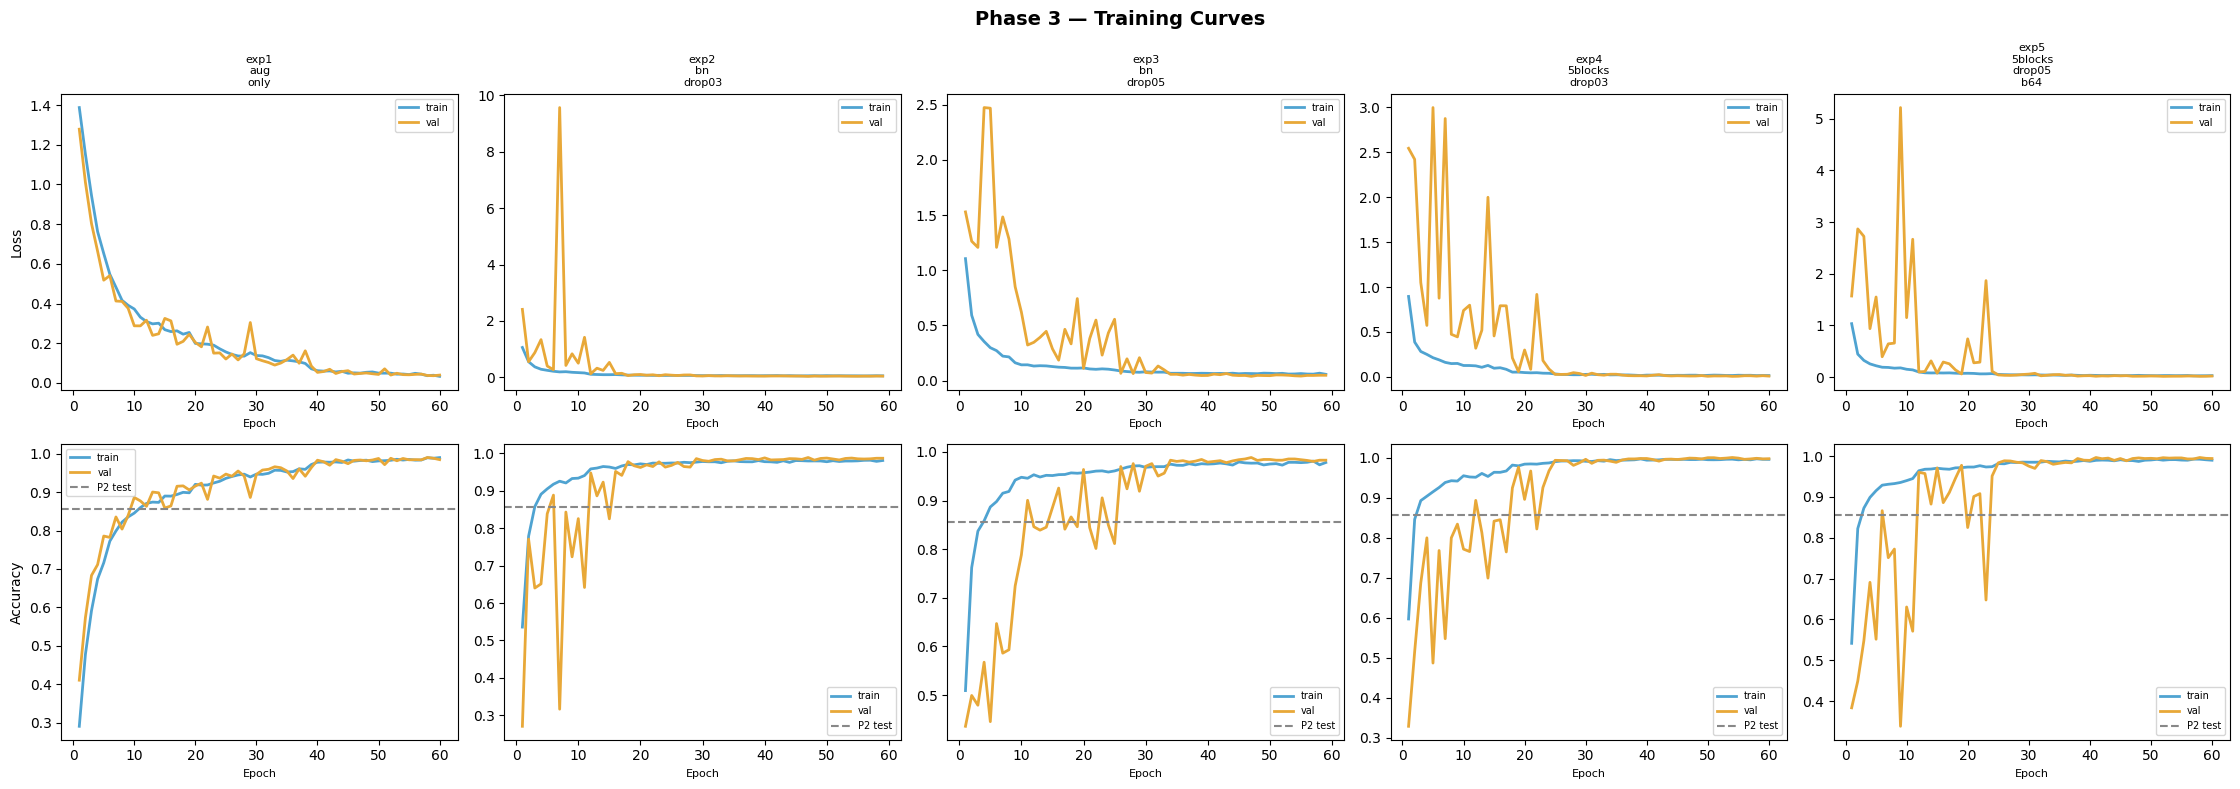

saved -> /mnt/e/University/University_Subjects/6th/Computational_Intelligence/Projects/2/CNN-IML/outputs/figures/phase3_01_training_curves.png


In [12]:
n_exp = len(results)
fig, axes = plt.subplots(2, n_exp, figsize=(4.5 * n_exp, 8))
fig.suptitle('Phase 3 — Training Curves', fontsize=14, fontweight='bold')

for col, (name, r) in enumerate(results.items()):
    h  = r['history']
    ep = range(1, len(h.history['loss']) + 1)

    axes[0, col].plot(ep, h.history['loss'],     color='#4FA3D1', lw=2, label='train')
    axes[0, col].plot(ep, h.history['val_loss'], color='#E8A838', lw=2, label='val')
    axes[0, col].set_title(name.replace('_', '\n'), fontsize=8)
    axes[0, col].set_xlabel('Epoch', fontsize=8)
    if col == 0:
        axes[0, col].set_ylabel('Loss')
    axes[0, col].legend(fontsize=7)

    axes[1, col].plot(ep, h.history['accuracy'],     color='#4FA3D1', lw=2, label='train')
    axes[1, col].plot(ep, h.history['val_accuracy'], color='#E8A838', lw=2, label='val')
    axes[1, col].axhline(PHASE2['test_acc'], color='#888888', lw=1.5, ls='--', label='P2 test')
    axes[1, col].set_xlabel('Epoch', fontsize=8)
    if col == 0:
        axes[1, col].set_ylabel('Accuracy')
    axes[1, col].legend(fontsize=7)

plt.tight_layout()
fig.savefig(FIGS / 'phase3_01_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'saved -> {FIGS / "phase3_01_training_curves.png"}')

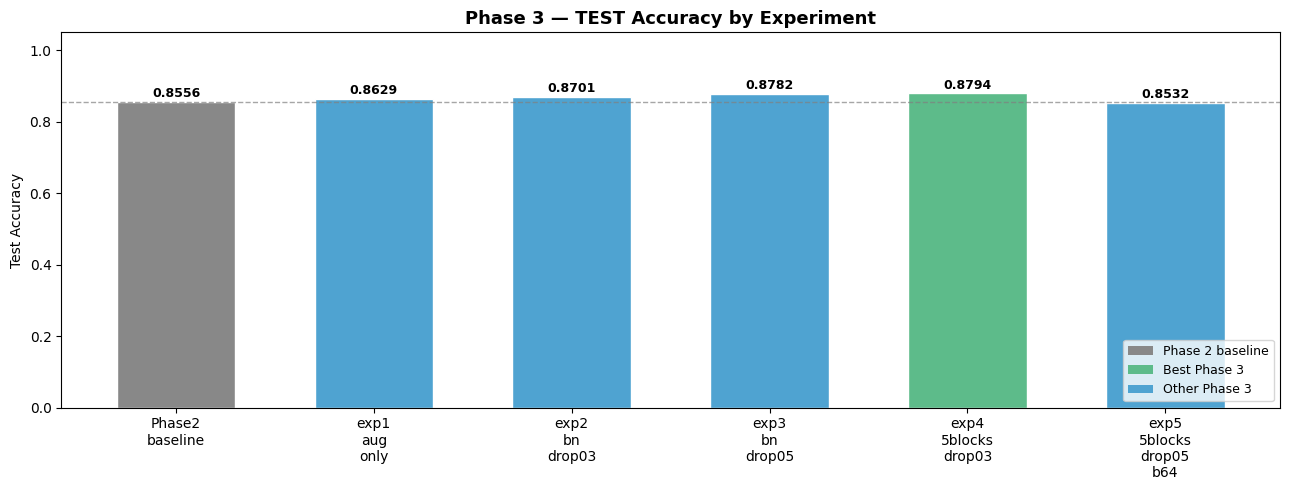

saved -> /mnt/e/University/University_Subjects/6th/Computational_Intelligence/Projects/2/CNN-IML/outputs/figures/phase3_02_experiment_comparison.png


In [13]:
names_plot = ['Phase2\nbaseline'] + [n.replace('_', '\n') for n in results]
test_accs  = [PHASE2['test_acc']] + [r['test_acc'] for r in results.values()]
bar_colors = ['#888888'] + [
    '#5DBB8A' if n == best_name else '#4FA3D1'
    for n in results
]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(names_plot, test_accs, color=bar_colors, edgecolor='white', width=0.6)

for bar, acc in zip(bars, test_accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{acc:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axhline(PHASE2['test_acc'], color='gray', lw=1, ls='--', alpha=0.7)
ax.set_ylabel('Test Accuracy')
ax.set_title('Phase 3 — TEST Accuracy by Experiment', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.05)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#888888', label='Phase 2 baseline'),
    Patch(facecolor='#5DBB8A', label='Best Phase 3'),
    Patch(facecolor='#4FA3D1', label='Other Phase 3'),
], loc='lower right', fontsize=9)

plt.tight_layout()
fig.savefig(FIGS / 'phase3_02_experiment_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'saved -> {FIGS / "phase3_02_experiment_comparison.png"}')

## 5. Best Model — Full TEST Evaluation

In [14]:
print(f'Best experiment : {best_name}')
print(f'TEST accuracy   : {results[best_name]["test_acc"]:.4f}')
print(f'TEST loss       : {results[best_name]["test_loss"]:.4f}')

y_true  = results[best_name]['y_true']
y_pred  = results[best_name]['y_pred']
y_proba = results[best_name]['y_proba']

Best experiment : exp4_5blocks_drop03
TEST accuracy   : 0.8794
TEST loss       : 0.6429


### 5.1 Classification Report

In [15]:
print(classification_report(y_true, y_pred, target_names=CLASSES))

              precision    recall  f1-score   support

  EOSINOPHIL       0.94      0.82      0.88       623
  LYMPHOCYTE       1.00      0.99      1.00       620
    MONOCYTE       0.99      0.75      0.85       620
  NEUTROPHIL       0.69      0.95      0.80       624

    accuracy                           0.88      2487
   macro avg       0.91      0.88      0.88      2487
weighted avg       0.91      0.88      0.88      2487



### 5.2 Confusion Matrix

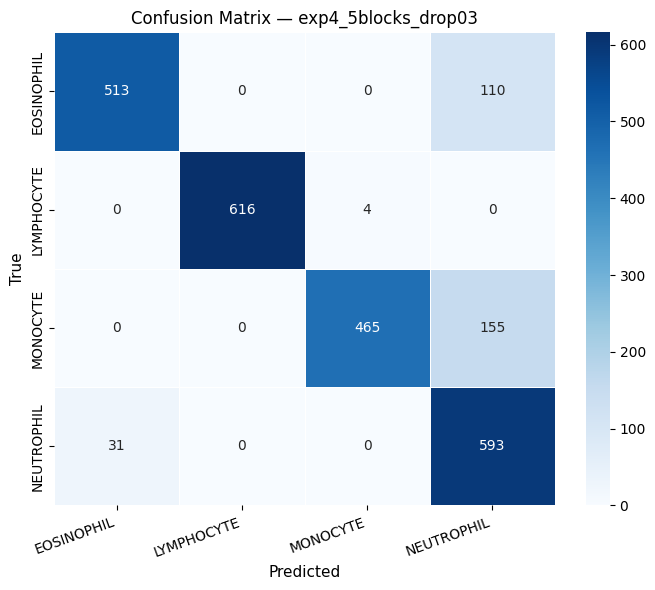

saved -> /mnt/e/University/University_Subjects/6th/Computational_Intelligence/Projects/2/CNN-IML/outputs/figures/phase3_03_confusion_matrix.png


In [16]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            ax=ax, linewidths=0.5)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True',      fontsize=11)
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=12)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
fig.savefig(FIGS / 'phase3_03_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'saved -> {FIGS / "phase3_03_confusion_matrix.png"}')

### 5.3 ROC Curves + AUC

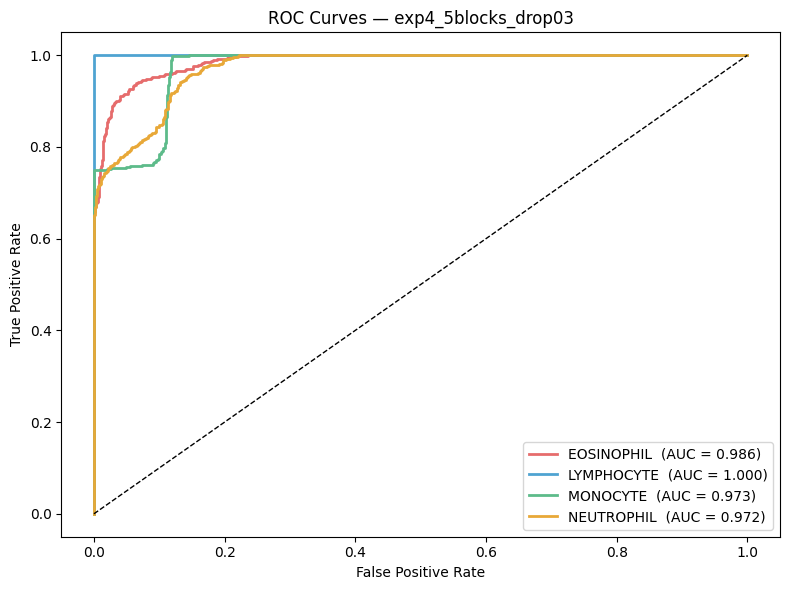


AUC per class:
  EOSINOPHIL     : 0.9861
  LYMPHOCYTE     : 1.0000
  MONOCYTE       : 0.9729
  NEUTROPHIL     : 0.9724
  Macro avg      : 0.9829


In [17]:
y_true_bin = label_binarize(y_true, classes=list(range(len(CLASSES))))

fig, ax = plt.subplots(figsize=(8, 6))
auc_scores = {}
for i, (cls, color) in enumerate(zip(CLASSES, COLORS)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
    score       = auc(fpr, tpr)
    auc_scores[cls] = score
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{cls}  (AUC = {score:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'ROC Curves — {best_name}', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
fig.savefig(FIGS / 'phase3_04_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nAUC per class:')
for cls, score in auc_scores.items():
    print(f'  {cls:15s}: {score:.4f}')
print(f'  Macro avg      : {np.mean(list(auc_scores.values())):.4f}')

### 5.4 Sample TEST Predictions

4 correct + up to 2 misclassified per class. Green title = correct, red = wrong.

Found 7968 images belonging to 4 classes.
Found 1989 images belonging to 4 classes.
Found 2487 images belonging to 4 classes.


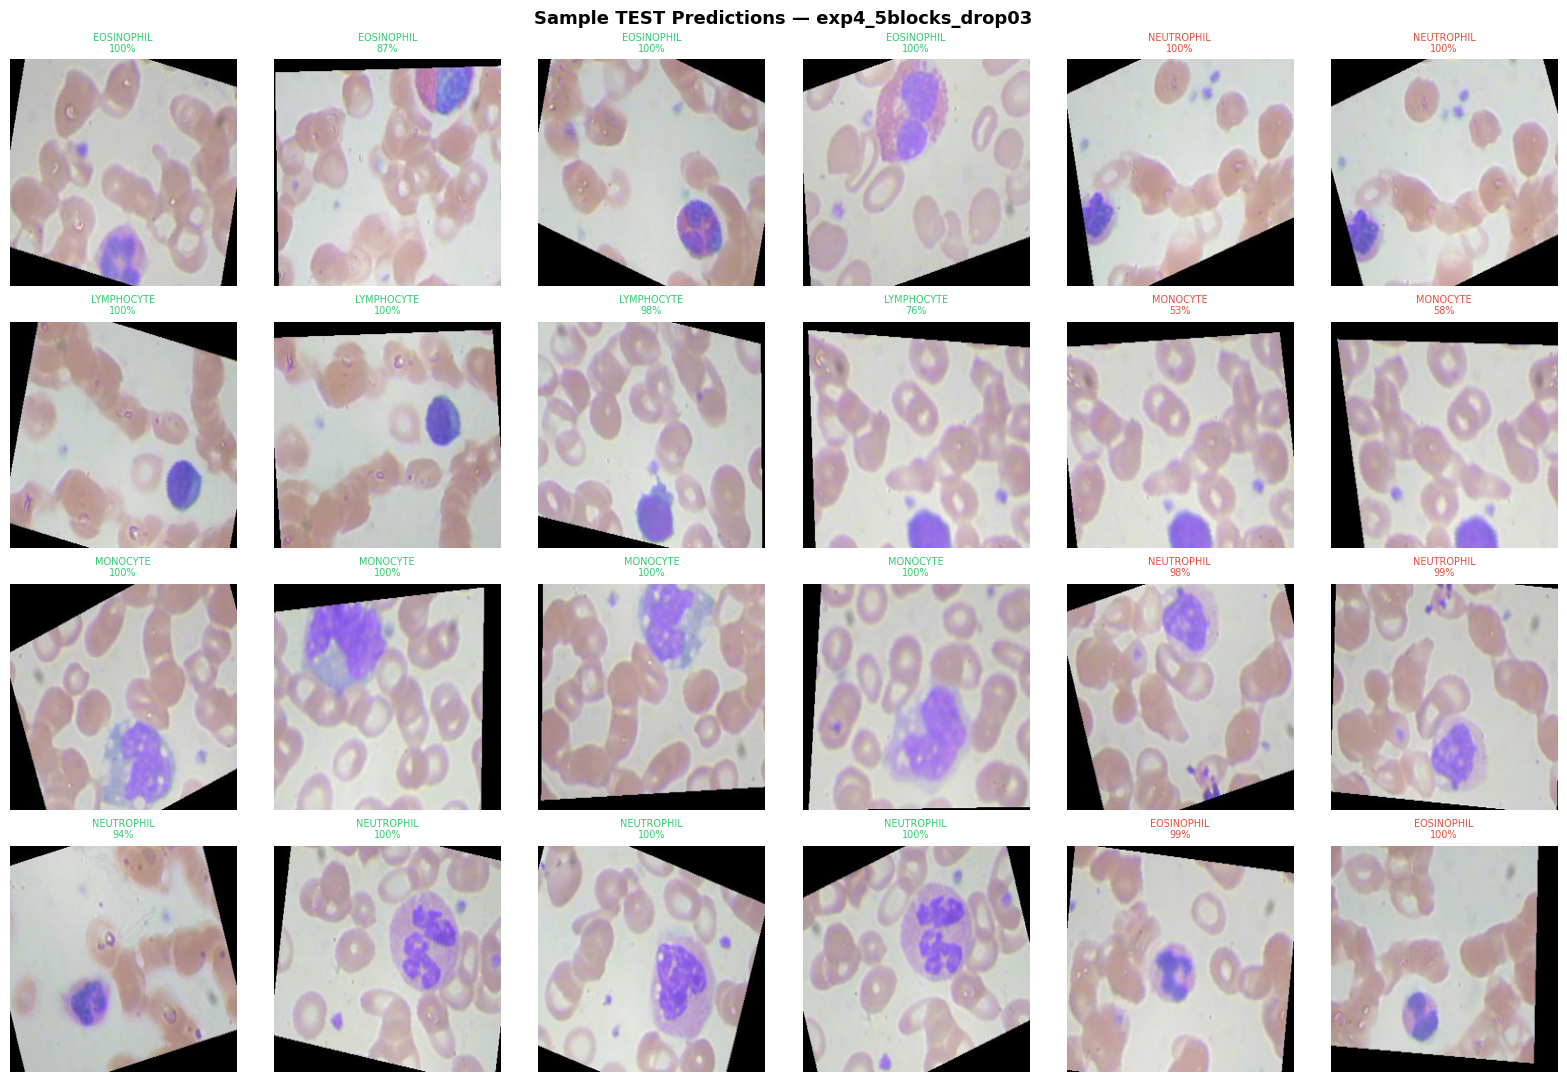

saved -> /mnt/e/University/University_Subjects/6th/Computational_Intelligence/Projects/2/CNN-IML/outputs/figures/phase3_05_sample_predictions.png


In [18]:
_, _, test_gen_vis = make_generators(
    target_size=results[best_name]['target_size'], batch_size=32)

best_model = tf.keras.models.load_model(results[best_name]['model_path'])
test_gen_vis.reset()
y_proba_vis = best_model.predict(test_gen_vis, verbose=0)
y_pred_vis  = np.argmax(y_proba_vis, axis=1)
y_true_vis  = test_gen_vis.classes
filepaths   = np.array(test_gen_vis.filepaths)

fig, axes = plt.subplots(4, 6, figsize=(16, 11))
fig.suptitle(f'Sample TEST Predictions — {best_name}', fontsize=13, fontweight='bold')

for row, cls_idx in enumerate(range(len(CLASSES))):
    cls_mask    = (y_true_vis == cls_idx)
    correct_idx = np.where(cls_mask & (y_pred_vis == y_true_vis))[0]
    wrong_idx   = np.where(cls_mask & (y_pred_vis != y_true_vis))[0]
    chosen      = (list(correct_idx[:4]) + list(wrong_idx[:2]))[:6]

    for col, idx in enumerate(chosen):
        img = Image.open(filepaths[idx]).resize(results[best_name]['target_size'])
        ax  = axes[row, col]
        ax.imshow(img)
        correct = (y_pred_vis[idx] == y_true_vis[idx])
        conf    = y_proba_vis[idx, y_pred_vis[idx]]
        title   = f'{CLASSES[y_pred_vis[idx]]}\n{conf:.0%}'
        ax.set_title(title, fontsize=7,
                     color='#2ecc71' if correct else '#e74c3c')
        ax.axis('off')

plt.tight_layout()
fig.savefig(FIGS / 'phase3_05_sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'saved -> {FIGS / "phase3_05_sample_predictions.png"}')

## 6. Phase 2 vs Phase 3 — Final Comparison

  PHASE 2  vs  PHASE 3  —  TEST SET COMPARISON
  Metric                            Phase 2         Phase 3     Delta
  ------------------------------------------------------------
  Accuracy                           0.8556          0.8794   +0.0237
  F1 (macro)                              —          0.8826
  Precision (macro)                       —          0.9064
  Recall (macro)                          —          0.8793

Best experiment : exp4_5blocks_drop03
TEST accuracy   : 0.8794  (+2.37% vs Phase 2)


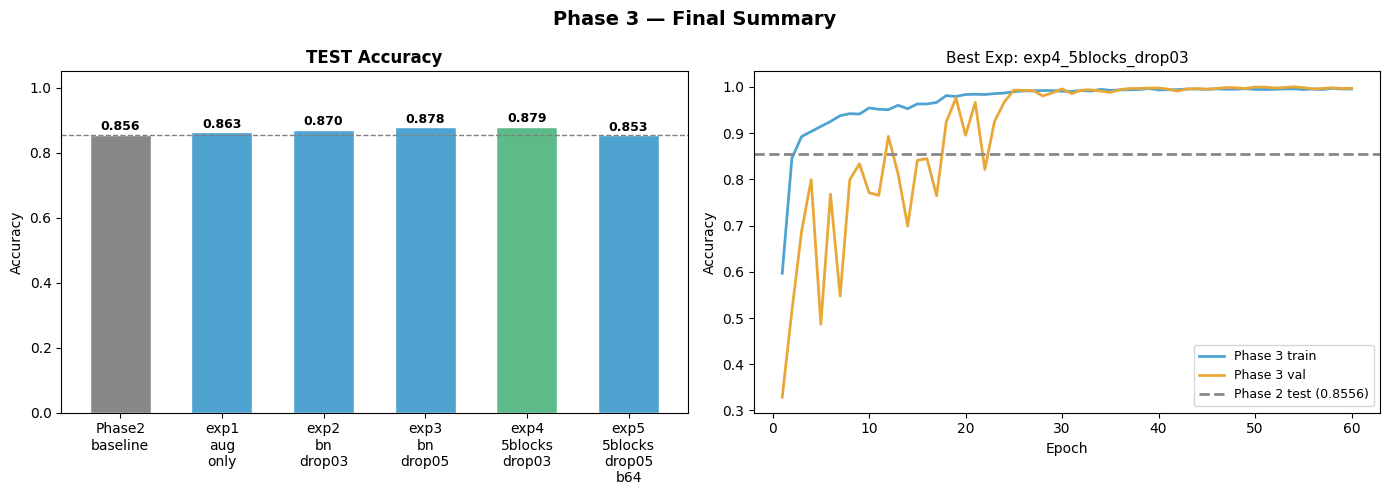

saved -> /mnt/e/University/University_Subjects/6th/Computational_Intelligence/Projects/2/CNN-IML/outputs/figures/phase3_06_final_comparison.png


In [19]:
prec, rec, f1, _ = precision_recall_fscore_support(
    results[best_name]['y_true'],
    results[best_name]['y_pred'],
    average='macro'
)

p2_acc = PHASE2['test_acc']
p3_acc = results[best_name]['test_acc']

print(f'{"="*65}')
print(f'  PHASE 2  vs  PHASE 3  —  TEST SET COMPARISON')
print(f'{"="*65}')
print(f'  {"Metric":<22} {"Phase 2":>18}  {"Phase 3":>14}  {"Delta":>8}')
print(f'  {"-"*60}')
print(f'  {"Accuracy":<22} {p2_acc:>18.4f}  {p3_acc:>14.4f}  {p3_acc-p2_acc:>+8.4f}')
print(f'  {"F1 (macro)":<22} {"—":>18}  {f1:>14.4f}')
print(f'  {"Precision (macro)":<22} {"—":>18}  {prec:>14.4f}')
print(f'  {"Recall (macro)":<22} {"—":>18}  {rec:>14.4f}')
print(f'{"="*65}')
print(f'\nBest experiment : {best_name}')
print(f'TEST accuracy   : {p3_acc:.4f}  ({(p3_acc-p2_acc)*100:+.2f}% vs Phase 2)')

# ---- Summary figure ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: all test accuracies
names_all  = ['Phase2\nbaseline'] + [n.replace('_', '\n') for n in results]
accs_all   = [p2_acc] + [r['test_acc'] for r in results.values()]
colors_all = ['#888888'] + [
    '#5DBB8A' if n == best_name else '#4FA3D1' for n in results
]
bars = axes[0].bar(names_all, accs_all, color=colors_all, edgecolor='white', width=0.6)
for bar, acc in zip(bars, accs_all):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{acc:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].axhline(p2_acc, color='gray', lw=1, ls='--')
axes[0].set_title('TEST Accuracy', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1.05)

# Right: best experiment training curves
h  = results[best_name]['history']
ep = range(1, len(h.history['accuracy']) + 1)
axes[1].plot(ep, h.history['accuracy'],     '#4FA3D1', lw=2, label='Phase 3 train')
axes[1].plot(ep, h.history['val_accuracy'], '#E8A838', lw=2, label='Phase 3 val')
axes[1].axhline(p2_acc, color='#888888', lw=2, ls='--',
                label=f'Phase 2 test ({p2_acc:.4f})')
axes[1].set_title(f'Best Exp: {best_name}', fontsize=11)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=9)

plt.suptitle('Phase 3 — Final Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGS / 'phase3_06_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'saved -> {FIGS / "phase3_06_final_comparison.png"}')